In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
customer_data = pd.read_csv("customer_data_with_churn_labels.csv")
customer_data.head()

,Customer ID,gross_revenue,frequency,AOV,recency_days,tenure_days,purchase_rate_monthly,avg_days_between,std_days_between,return_events,returned_quantity,purchased_quantity,return_rate,return_value,net_revenue,net_to_gross_ratio,churn_class
0,12346.0,372.86,11,33.896364,164,197,1.675127,6.000000,21.724076,4.0,17.0,70,0.242857,424.60,-51.74,-0.138765,churned
1,12347.0,1323.32,2,661.660000,2,38,1.578947,0.528571,4.422346,0.0,0.0,828,0.000000,0.00,1323.32,1.000000,active
2,12348.0,222.16,1,222.160000,73,1,30.000000,0.000000,0.000000,0.0,0.0,373,0.000000,0.00,222.16,1.000000,one_off_buyer
3,12349.0,2671.14,3,890.380000,42,182,0.494505,1.782178,16.200990,1.0,5.0,993,0.005035,24.15,2646.99,0.990959,active
4,12351.0,300.93,1,300.930000,10,1,30.000000,0.000000,0.000000,0.0,0.0,261,0.000000,0.00,300.93,1.000000,one_off_buyer


In [3]:
customer_data.shape

(4312, 17)

## Describe Features by Churn Class

To understand the characteristics of each churn class, I calculated descriptive statistics (mean, median, standard deviation, etc.) for key numerical features (e.g., 'recency_days', 'frequency', 'gross_revenue', 'purchase_rate_monthly', 'return_rate') grouped by 'churn_class'.

This highlighted initial differences between active, churned, and one_off_buyer groups.

In [4]:
selected_features = [
    'recency_days',
    'frequency',
    'gross_revenue',
    'purchase_rate_monthly',
    'return_rate'
]

churn_class_stats = customer_data.groupby('churn_class')[selected_features].describe()

display(churn_class_stats)

recency_days                                                     \
                     count        mean         std   min    25%    50%    75%   
churn_class                                                                     
active              2259.0   29.248340   24.146766   0.0    9.0   22.0   48.0   
churned              634.0  172.039432   66.315704  91.0  113.0  157.0  216.0   
one_off_buyer       1419.0  150.582100  114.323130   0.0   46.0  126.0  252.5   

                     frequency            ... purchase_rate_monthly         \
                 max     count      mean  ...                   75%    max   
churn_class                               ...                                
active          90.0    2259.0  6.921647  ...              1.265825  120.0   
churned        373.0     634.0  3.403785  ...              1.685015  120.0   
one_off_buyer  373.0    1419.0  1.000000  ...             30.000000   30.0   

              return_rate                                                    \
                    count      mean       std  min  25%       50%       75%   
churn_class                                                                   
active             2259.0  0.018665  0.101098  0.0  0.0  0.001289  0.010541   
churned             634.0  0.043272  0.183162  0.0  0.0  0.000000  0.014219   
one_off_buyer      1419.0  0.027663  0.178563  0.0  0.0  0.000000  0.000000   

                         
                    max  
churn_class              
active         3.000000  
churned        2.758305  
one_off_buyer  3.000000  

[3 rows x 40 columns]

In [8]:
customer_data.groupby("churn_class")[selected_features].mean()

,recency_days,frequency,gross_revenue,purchase_rate_monthly,return_rate
churn_class,,,,,
active,29.248340,6.921647,3314.558530,2.160422,0.018665
churned,172.039432,3.403785,1284.450394,6.415807,0.043272
one_off_buyer,150.582100,1.000000,349.756500,30.000000,0.027663


### Summary Findings:

Based on the descriptive statistics, I observed distinct patterns for each churn class:

**1. Active Customers:**
*   **Recency Days:** Have the lowest average recency (**around 29 days**) and a small standard deviation, indicating recent and consistent engagement.
*   **Frequency:** Show the highest average frequency (**around 6.9 transactions**), demonstrating regular purchases.
*   **Gross Revenue:** Exhibit a significantly higher average gross revenue (**£3,314.6**) compared to other groups, reflecting their continued spending.
*   **Purchase Rate Monthly:** Maintain a moderate and relatively stable purchase rate of at least **twice a month**.
*   **Return Rate:** Have a low average return rate (**0.02**), suggesting satisfaction with purchases and fewer returns.

**2. Churned Customers:**
*   **Recency Days:** Display a much higher average recency (**around 172 days**) than active customers, confirming their inactivity.
*   **Frequency:** Have a lower average frequency (**around 3.4 transactions**) compared to active customers, indicating *a drop-off in purchasing behavior*.
*   **Gross Revenue:** Generally have lower gross revenue (**£1,284.5**) than active customers.
*   **Purchase Rate Monthly:** The purchase rate is higher (**at least 6 times**) than active customers.
*   **Return Rate:** Have a slightly higher average return rate (**0.04**) than active customers, which could be a contributing factor to churn or *a sign of dissatisfaction*.

**3. One-Off Buyers:**
*   **Recency Days:** Their average recency (**around 150 days**) is high, similar to churned customers, as they only made a single purchase.
*   **Frequency:** By definition, their frequency is 1, as they have only made one purchase.
*   **Gross Revenue:** Their average gross revenue is the lowest among the groups (**£349.8**), consistent with their single purchase.
*   **Purchase Rate Monthly:** Tend to have a high calculated monthly purchase rate (**at least 30 times**) due to their one purchase within a short `tenure_days` (often 1 day), which is a characteristic of this metric for single-purchase customers.
*   **Return Rate:** Show a moderate return rate at **0.03**, but interpretation requires caution as it is based on a single transaction.



### **Key Insight:**
*   **Recency** is the strongest indicator separating active customers from churned and one-off buyers.
*   **Frequency** and **Gross Revenue** clearly differentiate active customers as the most valuable segment.
*   **Return Rate** shows active customers tend to return less, while churned customers have a slightly higher tendency to return items purchased, which could be an area for further investigation.
*   **One-off buyers** are distinct with their single transaction, and their high `purchase_rate_monthly` is an artifact of the calculation for single-day tenures.

## Visualize Key Churn Features

I visualized the distribution of selected features ('recency_days', 'frequency', 'gross_revenue', 'purchase_rate_monthly', and 'return_rate') across 'churn_class' categories to compare them.


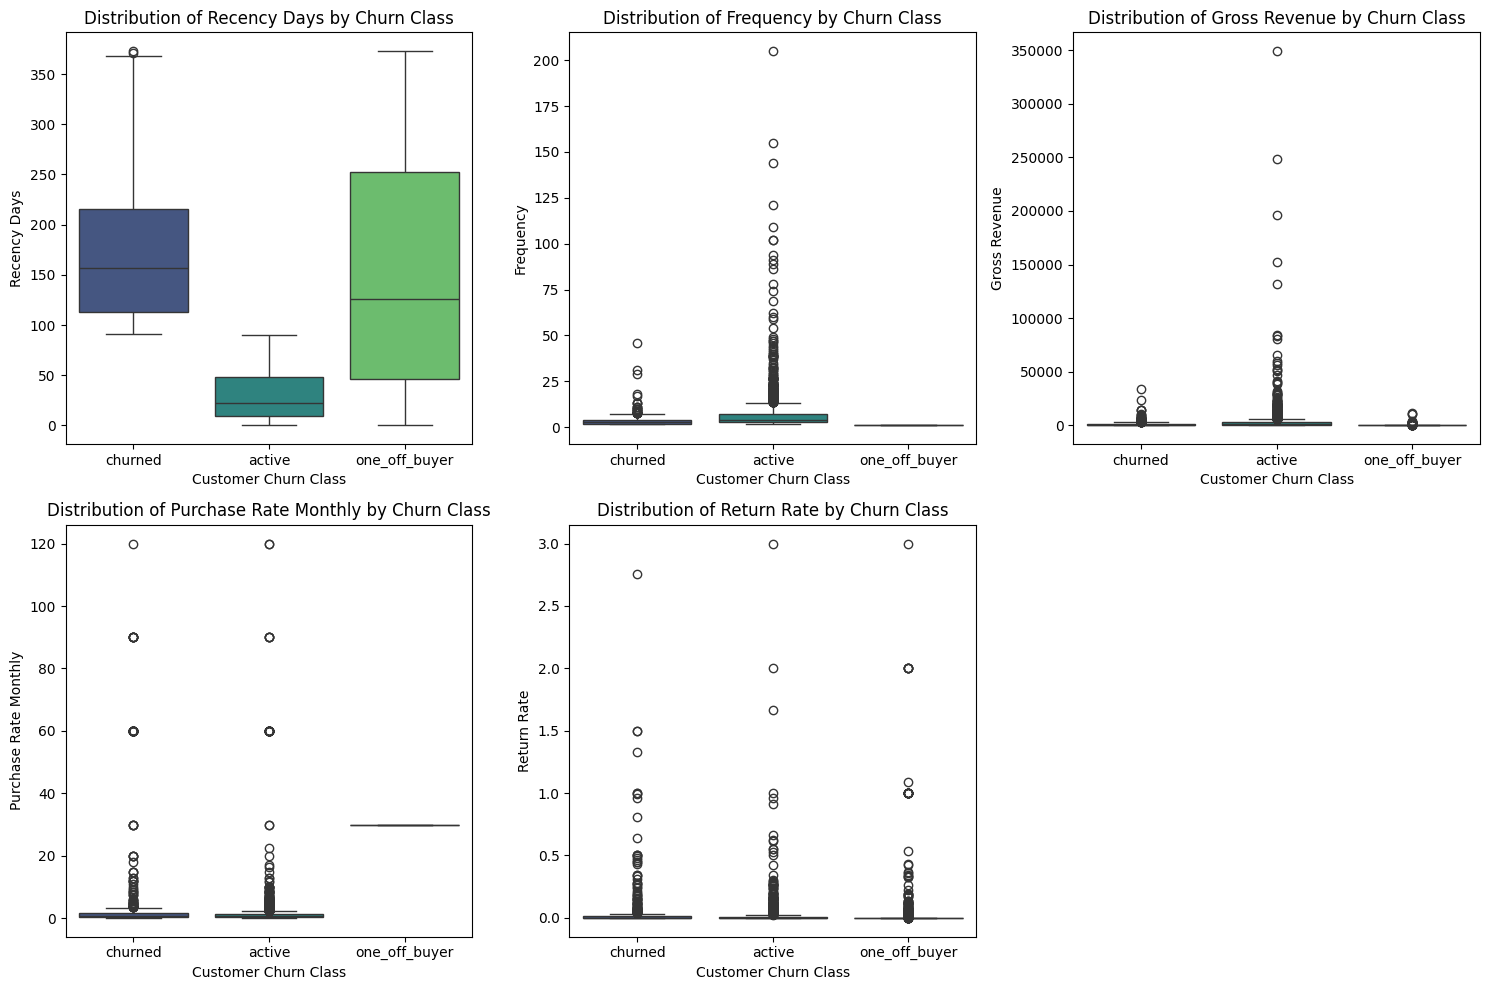

In [9]:
# Visualize feature distributions by churn class using boxplots
selected_features = [
    'recency_days',
    'frequency',
    'gross_revenue',
    'purchase_rate_monthly',
    'return_rate'
]

plt.figure(figsize=(15, 10))

for i, feature in enumerate(selected_features, 1):
    plt.subplot(2, 3, i)  # Adjust subplot grid as needed
    sns.boxplot(x='churn_class', y=feature, data=customer_data, palette='viridis')
    plt.title(f'Distribution of {feature.replace("_", " ").title()} by Churn Class')
    plt.xlabel('Customer Churn Class')
    plt.ylabel(feature.replace("_", " ").title())

plt.tight_layout()
plt.show()

### Summary:

The distribution of features provided a clear visual representation of the distinctions between 'active', 'churned', and 'one_off_buyer' customer segments:

**1. Recency Days:**
*   **Active Customers:** Show a tight distribution with very low recency days, reinforcing their recent engagement.
*   **Churned Customers:** Exhibit a significantly higher median and wider spread, indicating a longer time since their last purchase, as expected.
*   **One-Off Buyers:** Similar to churned customers, they have high recency, consistent with making only one purchase and then becoming inactive.

**2. Frequency:**
*   **Active Customers:** Have the highest median frequency and a wider range, signifying repeated purchases. There are also some outliers with very high frequencies.
*   **Churned Customers:** Display a lower median frequency than active customers, but still more than one-off buyers, confirming they made multiple purchases before churning.
*   **One-Off Buyers:** As defined, their frequency is exactly 1, represented by a single line in the box plot.

**3. Gross Revenue:**
*   **Active Customers:** Show the highest median gross revenue and a substantial spread, with many high-value outliers, highlighting their significant contribution to sales.
*   **Churned Customers:** Have a lower median gross revenue compared to active customers, though still higher than one-off buyers.
*   **One-Off Buyers:** Naturally, have the lowest gross revenue, corresponding to their single purchase.

**4. Purchase Rate Monthly:**
*   **Active Customers:** Exhibit a more consistent, but not necessarily very high, monthly purchase rate.
*   **Churned Customers:** Generally have a lower purchase rate compared to active customers.
*   **One-Off Buyers:** Show an artificially high 'purchase_rate_monthly' often due to their `tenure_days` being 1. This metric is less informative for this group, as it inflates the rate for a single transaction.

**5. Return Rate:**
*   **Active Customers:** Tend to have lower return rates, with many customers having a 0 return rate, indicating higher satisfaction or fewer issues with products.
*   **Churned Customers:** Show a slightly higher median return rate and a broader distribution compared to active customers, suggesting that return behavior might contribute to or be an indicator of dissatisfaction leading to churn.
*   **One-Off Buyers:** Have a varied return rate, but it is often hard to interpret for single transactions. There are also some high outliers which might suggest issues with their initial purchase experience.


### **Overall Insights:**

*   The visualizations clearly reinforce the definitions of the churn classes, with 'recency_days', 'frequency', and 'gross_revenue' being the most differentiating features.
*   The presence of outliers, especially in 'gross_revenue' for active customers, indicates the importance of high-value customers.
*   The 'purchase_rate_monthly' metric needs careful interpretation for one-off buyers.
*   'Return rate' shows interesting patterns, where active customers tend to have lower rates, while churned customers might have higher tendencies to return, warranting further investigation into return reasons.

## Data Analysis Key Findings

*   **Recency Days** is a primary differentiator: Active customers have significantly lower average recency (about **29 days**) compared to churned customers (about **172 days**) and one-off buyers (approximately **150 days**), *indicating recent engagement for active customers and inactivity for the other groups*.

*   **Frequency** effectively distinguishes active customers: Active customers show the highest average frequency (**6.9 transactions**), while churned customers have a lower average (**3.4 transactions**), and one-off buyers, by definition, have a frequency of 1.

*   **Gross Revenue** highlights *customer value*: Active customers exhibit significantly higher average gross revenue (**£3,314.6**), with a substantial spread and high-value outliers, *reflecting their continued spending*. Churned customers have lower gross revenue (**£1,284.5**) than active customers, but higher than one-off buyers, who naturally have the lowest (**£349.8**).

*   **Return Rate** shows potential churn indicators: Active customers tend to have lower average return rates (**0.02**), suggesting higher satisfaction. Churned customers have a slightly higher average return rate (**0.04**) than active customers, which could *indicate dissatisfaction* or contribute to churn.

*   **Purchase Rate Monthly** requires careful interpretation for one-off buyers: While active and churned customers show moderate (**2.2**) and lower rates (**6.4**) respectively, one-off buyers often display an artificially high rate of **30 transactions** due to their single transaction within a short tenure, making this metric less informative for this specific group.


## **Recommendations for Next Steps:**

*   **Focus on Recency and Engagement for Churn Prevention:** Given that 'recency_days' is the strongest indicator of churn, implement proactive strategies to re-engage customers as their recency days increase, before they transition into the 'churned' category.

*   **Investigate Return Patterns for Churned Customers:** The slightly higher return rate among churned customers suggests that *product dissatisfaction or issues with returns* could be a contributing factor to churn; further analysis into the reasons for returns in this segment might reveal actionable insights.
